In [1]:
import operator
from pathlib import Path
from typing import TypedDict
from dotenv import load_dotenv
from typing import Annotated, List
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()


from rich.console import Console
from rich.pretty import Pretty
from rich.theme import Theme
from rich.markdown import Markdown

theme = Theme(
    {
        "json.key": "#c1a2ff",
        "json.string": "#FCCEA1",
        "json.number": "#A1C4FD",
        "json.boolean": "#A6F5D8",
        "json.null": "#ffb3ba",
    }
)

console = Console(
    theme=theme,
    force_terminal=True,
    force_jupyter=False,
    color_system="truecolor",
)


In [2]:
# op schema
class LlmSchema(BaseModel):
    score: float = Field(
        description="The assigned performance score for this specific criteria, evaluated on a scale from 0.0 to 10.0.",
        ge=0,
        le=10,
    )
    feedback: str = Field(
        description="""A Markdown numbered list containing 5-10 feedback items.

Each item must follow this format:

1. **Keyword Optimization**
   Explanation of the observation, its impact, and actionable recommendation.

2. **Heading Structure**
   Explanation of the observation, its impact, and actionable recommendation.

Requirements:
- Every item must begin with a numbered list marker.
- Every item must contain a bold Markdown heading.
- Every heading must be concise (2-5 words).
- Each heading must be followed by 1-3 explanatory sentences.
- Leave a blank line between items.
- Return only the Markdown list."""
    )

In [3]:
# model
def get_model(**kwargs):
    model = ChatGoogleGenerativeAI(**kwargs)
    structured_model = model.with_structured_output(LlmSchema)
    return structured_model

In [4]:
# state
class BlogState(TypedDict):
    blog_content: str

    content_quality_score: float
    content_quality_feedback: str

    cta_score: float
    cta_feedback: str

    seo_score: float
    seo_feedback: str

    scores: Annotated[list[float], operator.add]
    average_score: float

In [5]:
def evaluate_content_quality(state: BlogState):
    system_prompt = """You are an expert Content Editor and UX Writer. Your task is to evaluate the readability, tone, and audience alignment of the provided blog draft.

Analyze the text based on:
1. Formatting for digital readers (use of short paragraphs, bullet points, and bold text for skimmability).
2. Sentence mechanics (avoidance of excessive passive voice, complex jargon, and overly long sentences).
3. Tone consistency (maintaining the specified brand voice and meeting the target audience's expectations).

You must output your evaluation strictly matching the requested schema, containing a detailed feedback string and a score from 0.0 to 10.0."""

    user_prompt = """Evaluate the readability, tone, and audience alignment of the following blog post.

<blog_content>
{blog_content}
</blog_content>
"""

    prompt = ChatPromptTemplate(
        [
            ("system", system_prompt),
            ("user", user_prompt),
        ]
    )

    model = get_model(
        model="gemini-2.5-flash",
        temperature=0,
        max_output_tokens=5000,
    )

    chain = prompt | model

    res = chain.invoke({"blog_content": state["blog_content"]})
    return {
        "content_quality_score": res.score,
        "content_quality_feedback": res.feedback,
        "scores": [res.score],
    }


In [6]:
def evaluate_cta(state: BlogState):
    system_prompt = """You are a Conversion Rate Optimization (CRO) and Content Marketing Specialist. Your task is to evaluate how effectively the blog post fulfills its intended business or informational goal.

Analyze the text based on:
1. The Hook (whether the introduction instantly captures attention and states the value proposition).
2. Value Delivery (whether the core body paragraphs thoroughly answer the reader's intent without fluff).
3. Call to Action (whether the conclusion provides a clear, compelling, and logical next step for the reader).

You must output your evaluation strictly matching the requested schema, containing a detailed feedback string and a score from 0.0 to 10.0."""

    user_prompt = """Evaluate the value proposition and Call to Action (CTA) effectiveness of the following blog post.

<blog_content>
{blog_content}
</blog_content>
"""

    prompt = ChatPromptTemplate(
        [
            ("system", system_prompt),
            ("user", user_prompt),
        ]
    )

    model = get_model(
        model="gemini-2.5-flash",
        temperature=0,
        max_output_tokens=5000,
    )

    chain = prompt | model

    res = chain.invoke({"blog_content": state["blog_content"]})
    return {
        "cta_score": res.score,
        "cta_feedback": res.feedback,
        "scores": [res.score],
    }


In [7]:
def evaluate_seo(state: BlogState):
    system_prompt = """You are an expert SEO Strategist. Your task is to evaluate the provided blog post draft for Search Engine Optimization (SEO) best practices.

Analyze the text based on:
1. Keyword integration (natural density, placement in the introduction, and avoid keyword stuffing).
2. Structural hierarchy (effective use of headings like H2 and H3 for scannability).
3. Meta and linking readiness (suitability for search snippets, opportunities for internal or external links).

You must output your evaluation strictly matching the requested schema, containing a detailed feedback string and a score from 0.0 to 10.0."""

    user_prompt = """Evaluate the SEO and keyword optimization quality of the following blog post.

<blog_content>
{blog_content}
</blog_content>
"""

    prompt = ChatPromptTemplate(
        [
            ("system", system_prompt),
            ("user", user_prompt),
        ]
    )

    model = get_model(
        model="gemini-2.5-flash",
        temperature=0,
        max_output_tokens=5000,
    )

    chain = prompt | model

    res = chain.invoke({"blog_content": state["blog_content"]})
    return {
        "seo_score": res.score,
        "seo_feedback": res.feedback,
        "scores": [res.score],
    }


In [8]:
def calculate_average_score(state: BlogState):
    return {
        "average_score": round(
            sum(state["scores"]) / len(state["scores"]),
            2,
        )
        if state["scores"]
        else 0.0
    }

In [9]:
# init graph
graph = StateGraph(BlogState)

In [10]:
# add nodes
graph.add_node("evaluate_content_quality", evaluate_content_quality)
graph.add_node("evaluate_cta", evaluate_cta)
graph.add_node("evaluate_seo", evaluate_seo)
graph.add_node("calculate_average_score", calculate_average_score)

In [11]:
# add edges
graph.add_edge(START, "evaluate_content_quality")
graph.add_edge(START, "evaluate_cta")
graph.add_edge(START, "evaluate_seo")

graph.add_edge("evaluate_content_quality", "calculate_average_score")
graph.add_edge("evaluate_cta", "calculate_average_score")
graph.add_edge("evaluate_seo", "calculate_average_score")
graph.add_edge("calculate_average_score", END)

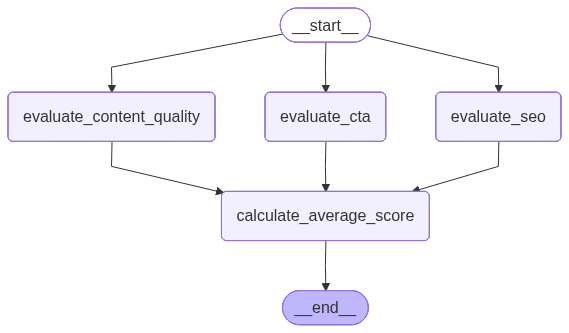

In [12]:
# compilattion
workflow = graph.compile()
workflow

In [13]:
# blog content from seqential workflow
with open("../1-SequentialWorkflow/files/2-blog_content.md", "r") as f:
    blog_content = f.read()

console.print(Markdown(blog_content))

              Exoplanets: Unveiling Worlds Beyond Our Solar System              

I. Introduction: A Universe of Other Worlds                                     

A. The Age-Old Question: For millennia, humanity has gazed at the night sky,    
wondering if we are alone. Are those twinkling lights merely distant suns, or do
they too host planets, perhaps even life? This profound curiosity, woven into   
the fabric of human thought, has driven poets, philosophers, and scientists     
alike.                                                                          

B. Defining Exoplanets: For most of history, this question remained firmly in   
the realm of speculation. But no longer. An exoplanet (or extrasolar planet) is 
simply defined as a planet that orbits a star other than our Sun. Their         
discovery, once a distant dream, has revolutionized our understanding of the    
universe, transforming our solar system from a unique cosmic anomaly into just  
one of countless planetar

In [14]:
# execution
final_state = workflow.invoke({"blog_content": blog_content, "scores": []})

In [15]:
console.print_json(data=final_state)


{
  "blog_content": "# Exoplanets: Unveiling Worlds Beyond Our Solar System\n\n## I. Introduction: A Universe of Other Worlds\n\n**A. The Age-Old Question:** For millennia, humanity has gazed at the night sky, wondering if we are alone. Are those twinkling lights merely distant suns, or do they too host planets, perhaps even life? This profound curiosity, woven into the fabric of human thought, has driven poets, philosophers, and scientists alike.\n\n**B. Defining Exoplanets:** For most of history, this question remained firmly in the realm of speculation. But no longer. An **exoplanet** (or extrasolar planet) is simply defined as a planet that orbits a star other than our Sun. Their discovery, once a distant dream, has revolutionized our understanding of the universe, transforming our solar system from a unique cosmic anomaly into just one of countless planetary systems.\n\n**C. Why Study Exoplanets?** The scientific pursuit of exoplanets is driven by several compelling motivations:\n

In [16]:
console.print_json(
    data={
        k: v
        for k, v in final_state.items()
        if k in ["content_quality_score", "cta_score", "seo_score", "average_score"]
    }
)

{
  "content_quality_score": 9.0,
  "cta_score": 7.5,
  "seo_score": 9.6,
  "average_score": 8.7
}


In [17]:
console.print(Markdown(final_state["blog_content"]))


              Exoplanets: Unveiling Worlds Beyond Our Solar System              

I. Introduction: A Universe of Other Worlds                                     

A. The Age-Old Question: For millennia, humanity has gazed at the night sky,    
wondering if we are alone. Are those twinkling lights merely distant suns, or do
they too host planets, perhaps even life? This profound curiosity, woven into   
the fabric of human thought, has driven poets, philosophers, and scientists     
alike.                                                                          

B. Defining Exoplanets: For most of history, this question remained firmly in   
the realm of speculation. But no longer. An exoplanet (or extrasolar planet) is 
simply defined as a planet that orbits a star other than our Sun. Their         
discovery, once a distant dream, has revolutionized our understanding of the    
universe, transforming our solar system from a unique cosmic anomaly into just  
one of countless planetar

In [18]:
Path("files").mkdir(exist_ok=True)

with open("./files/content_quality_feedback.md", "w") as f:
    f.write(f"Content Quality Score : {final_state['content_quality_score']}\n")
    f.write(final_state["content_quality_feedback"])

console.print(Markdown(final_state["content_quality_feedback"]))


 1 Paragraph Length While main sections use short paragraphs effectively, some  
   explanations within bulleted lists (e.g., under "Radial Velocity" or "Transit
   Photometry") are quite dense. This can make it harder for digital readers to 
   quickly digest complex information, even with the bullet point structure.    
   Break down longer explanatory paragraphs within bullet points into 1-2       
   shorter sentences or use internal bolding for key phrases to enhance         
   skimmability.                                                                
 2 Active Voice Usage The text occasionally uses passive voice (e.g.,           
   "exoplanets have been confirmed," "the scientific pursuit... is driven by"). 
   While not excessive, active voice generally creates more direct, concise, and
   engaging prose. Review sentences for opportunities to rephrase in active     
   voice, making the subject performing the action clear and strengthening the  
   sentence structure.     

In [19]:
with open("./files/cta_feedback.md", "w") as f:
    f.write(f"CTA Score : {final_state['cta_score']}\n")
    f.write(final_state["cta_feedback"])

console.print(Markdown(final_state["cta_feedback"]))



 1 Engaging Introduction The introduction effectively captures attention by     
   addressing a universal human curiosity and clearly defining exoplanets. It   
   sets a strong foundation for the deep dive, making the value proposition     
   immediately clear to the reader.                                             
 2 Exceptional Value Delivery The core body paragraphs provide an incredibly    
   thorough and well-researched exploration of exoplanets, covering history,    
   detection, characterization, diversity, and future prospects. The content is 
   rich in detail and free of fluff, directly addressing a reader's intent for  
   comprehensive information.                                                   
 3 Structured Clarity The post utilizes clear headings, sub-headings, and bullet
   points, making complex scientific concepts digestible and easy to follow.    
   This excellent structure enhances readability and ensures effective knowledge
   transfer without overwhe

In [20]:
with open("./files/seo_feedback.md", "w") as f:
    f.write(f"SEO Score : {final_state['seo_score']}\n")
    f.write(final_state["seo_feedback"])

console.print(Markdown(final_state["seo_feedback"]))



 1 Keyword Optimization The primary keyword "exoplanets" is perfectly integrated
   into the title, introduction, and throughout the body, maintaining a natural 
   density without stuffing. This ensures high relevance for search engines and 
   clearly communicates the article's focus.                                    
 2 Heading Structure The article utilizes a robust hierarchical structure with  
   clear H1, H2, and H3 (via A, B, C sub-sections) headings. This excellent     
   organization significantly enhances scannability and user experience, making 
   complex information digestible.                                              
 3 Meta Description Readiness The introductory sections (I. Introduction: A     
   Universe of Other Worlds) are rich in keywords and provide a concise overview
   of the article's scope. This content is highly suitable for crafting an      
   engaging and informative meta description that will attract clicks from      
   search results.         